In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from scipy.io import loadmat
from scipy.linalg import svd
from sklearn.model_selection import KFold
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['font.size'] = 14
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['font.family'] = 'Arial'

In [3]:
df = pd.read_csv('data/behavior_data/behavior_data.csv')
df.head()

,trialNum,firstVal,secondVal,firstIsChosen,decisionRT,firstFixLat,secondFixLat,thirdFixLat,session,monkey_id,chosenVal
0,6,1,3,0,0.827066,0.162,0.510,NaN,1,0,3.0
1,11,1,2,1,0.847049,0.164,0.372,0.616,1,0,1.0
2,18,1,5,0,0.897351,0.166,0.414,NaN,1,0,5.0
3,61,1,1,0,0.877376,0.163,0.415,NaN,1,0,1.0
4,62,1,5,0,0.937264,0.178,0.430,NaN,1,0,5.0


In [4]:
with open('data/neural_data/neural_data.p', 'rb') as f:
    spikes = pickle.load(f)

print(len(spikes)) # (n_sessions)
print(spikes[0].shape) # (n_trials, n_timesteps, n_cells, 3)

32
(587, 70, 22, 3)


In [5]:
bin_edges = loadmat('data/mcginty_and_lupkin_data_for_mattar_lab.mat')['metaData'][0][0][1]
bin_edges = np.round(bin_edges, 3)
bin_edges

array([[-0.2 , -0.19],
       [-0.19, -0.18],
       [-0.18, -0.17],
       [-0.17, -0.16],
       [-0.16, -0.15],
       [-0.15, -0.14],
       [-0.14, -0.13],
       [-0.13, -0.12],
       [-0.12, -0.11],
       [-0.11, -0.1 ],
       [-0.1 , -0.09],
       [-0.09, -0.08],
       [-0.08, -0.07],
       [-0.07, -0.06],
       [-0.06, -0.05],
       [-0.05, -0.04],
       [-0.04, -0.03],
       [-0.03, -0.02],
       [-0.02, -0.01],
       [-0.01, -0.  ],
       [ 0.  ,  0.01],
       [ 0.01,  0.02],
       [ 0.02,  0.03],
       [ 0.03,  0.04],
       [ 0.04,  0.05],
       [ 0.05,  0.06],
       [ 0.06,  0.07],
       [ 0.07,  0.08],
       [ 0.08,  0.09],
       [ 0.09,  0.1 ],
       [ 0.1 ,  0.11],
       [ 0.11,  0.12],
       [ 0.12,  0.13],
       [ 0.13,  0.14],
       [ 0.14,  0.15],
       [ 0.15,  0.16],
       [ 0.16,  0.17],
       [ 0.17,  0.18],
       [ 0.18,  0.19],
       [ 0.19,  0.2 ],
       [ 0.2 ,  0.21],
       [ 0.21,  0.22],
       [ 0.22,  0.23],
       [ 0.

In [6]:
from scipy.linalg import svd
from sklearn.linear_model import LassoCV


def stratified_train_test_split(df_session, test_size = 0.3, random_state = 42):
    """
    Stratified split ensuring balanced distribution of trial types.
    Stratify by first and second offer values.
    """

    np.random.seed(random_state)
    
    # create stratification key
    strat_key = df_session['firstVal'].astype(str) + '_' + df_session['secondVal'].astype(str)
    unique_strats = strat_key.unique()
    
    train_indices = []
    test_indices = []
    
    for strat in unique_strats:
        strat_indices = np.where(strat_key == strat)[0]
        n_test = max(1, int(len(strat_indices) * test_size))
        
        # shuffle and split
        shuffled = np.random.permutation(strat_indices)
        test_indices.extend(shuffled[:n_test])
        train_indices.extend(shuffled[n_test:])
    
    return np.array(train_indices), np.array(test_indices)


def fit_lasso_decoder(X_train, y_train):
    """
    Fit LASSO model with 10-fold cross-validation to select lambda.
    Returns fitted model.
    """

    # use LassoCV for automatic lambda selection via cross-validation
    # alphas: regularization strengths to try (lambda in the paper)
    alphas = np.logspace(-3, 1, 100)
    
    lasso_cv = LassoCV(
        alphas = alphas,
        cv = 10, # 10-fold cross-validation as specified in paper
        max_iter = 10000,
        random_state = 42,
        n_jobs = -1
    )
    
    lasso_cv.fit(X_train, y_train)
    
    return lasso_cv


def compute_value_weights_for_session(X_train, y1_train, y2_train):
    """
    Compute beta1 and beta2 (LASSO weights) for a single session.
    
    Returns:
        beta1, beta2: weight vectors
    """

    # fit LASSO for 1st value
    lasso1 = fit_lasso_decoder(X_train, y1_train)
    beta1 = lasso1.coef_
    
    # fit LASSO for 2nd value
    lasso2 = fit_lasso_decoder(X_train, y2_train)
    beta2 = lasso2.coef_
    
    return beta1, beta2


def find_value_subspace_basis(beta1, beta2, X):
    """
    Find orthonormal basis for value subspace using Semedo et al. method.
    
    Parameters:
        beta1: weights from LASSO model for 1st value (n_cells,)
        beta2: weights from LASSO model for 2nd value (n_cells,)
        X: spike count matrix (n_trials, n_cells)
    
    Returns:
        Q: orthonormal basis for value subspace (n_cells, 2)
    """
    
    # concatenate weight vectors into n x 2 matrix B
    B = np.column_stack([beta1, beta2]) # (n_cells, 2)
    
    # compute covariance matrix of spike data
    cov_X = np.cov(X.T)
    
    # compute M = B^T × cov(X)
    M = B.T @ cov_X
    
    # SVD of M
    U, D, Vt = svd(M, full_matrices=False)
    V = Vt.T
    
    # take first 2 columns of V (corresponding to non-zero singular values)
    Q = V[:, :2] # (n_cells, 2)
    
    return Q

In [11]:
# initialize storage for all sessions
r2s = []
r2s_2d = []

n_time_windows = len(np.arange(0, 51, 10))
time_windows = np.arange(0, 51, 10)
time_seconds = np.array([-0.1, 0, 0.1, 0.2, 0.3, 0.4])

for i_session in range(32):
    
    if i_session in [11, 19, 29, 30]:  # skip failed sessions
        continue

    # get session data
    df_session = df[df['session'] == i_session + 1]
    spikes_session = spikes[i_session]
    
    df_session = df_session.reset_index(drop = True)
    first_val = df_session['firstVal'].values
    second_val = df_session['secondVal'].values
    
    # train-test split
    train_idx, test_idx = stratified_train_test_split(
        pd.DataFrame({'firstVal': first_val, 'secondVal': second_val}),
        test_size = 0.3
    )
    
    # compute value axes using 0.2-0.4s after second fixation
    start_idx_train = 40
    end_idx_train = 59
    alignment = 1
    X = spikes_session[:, start_idx_train:end_idx_train, :, alignment].mean(axis = 1)
    X_train = X[train_idx]
    y1_train = first_val[train_idx]
    y2_train = second_val[train_idx]

    # compute betas
    beta1, beta2 = compute_value_weights_for_session(
        X_train, y1_train, y2_train
    )
    
    # compute value subspace basis (using training data covariance)
    Q = find_value_subspace_basis(beta1, beta2, X_train)
    
    # loop through time windows
    r2s_session = []
    r2s_2d_session = []
    
    for start_idx in np.arange(0, 51, 10):
        end_idx = start_idx + 19
        
        # average spike counts over the epoch
        X = spikes_session[:, start_idx: end_idx, :, alignment].mean(axis = 1)
        X_train, X_test = X[train_idx], X[test_idx]
        y1_train, y1_test = first_val[train_idx], first_val[test_idx]
        y2_train, y2_test = second_val[train_idx], second_val[test_idx]

        # fit LASSO decoder
        model1 = fit_lasso_decoder(X_train, y1_train)
        y1_pred = model1.predict(X_test)

        model2 = fit_lasso_decoder(X_train, y2_train)
        y2_pred = model2.predict(X_test)

        r2s_session.append(np.array([r2_score(y1_test, y1_pred), r2_score(y2_test, y2_pred)]))


        # average spike counts over the epoch
        X = spikes_session[:, start_idx: end_idx, :, alignment].mean(axis = 1) @ Q 
        X_train, X_test = X[train_idx], X[test_idx]
        y1_train, y1_test = first_val[train_idx], first_val[test_idx]
        y2_train, y2_test = second_val[train_idx], second_val[test_idx]

        # fit LASSO decoder
        model1 = fit_lasso_decoder(X_train, y1_train)
        y1_pred = model1.predict(X_test)

        model2 = fit_lasso_decoder(X_train, y2_train)
        y2_pred = model2.predict(X_test)

        r2s_2d_session.append(np.array([r2_score(y1_test, y1_pred), r2_score(y2_test, y2_pred)]))
    
    r2s_session = np.array(r2s_session)
    r2s_2d_session = np.array(r2s_2d_session)

    r2s.append(r2s_session)
    r2s_2d.append(r2s_2d_session)

r2s = np.array(r2s)
r2s_2d = np.array(r2s_2d)

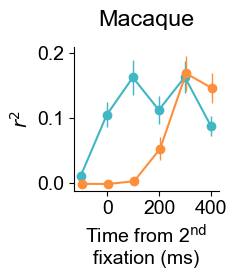

In [13]:
means = np.mean(r2s_2d, axis = 0)
errors = np.std(r2s_2d, axis = 0, ddof = 1) / np.sqrt(r2s.shape[0])

colors = ['#41b6c4', '#fd8f3c']

plt.figure(figsize = (2.6, 3))

plt.errorbar(time_seconds - 0.0025, means[:, 0], yerr = errors[:, 0], fmt = 'o-', color = colors[0], ecolor = colors[0], elinewidth = 1, capsize = 0, label = r'1$^\text{st}$ item')
plt.errorbar(time_seconds + 0.0025, means[:, 1], yerr = errors[:, 1], fmt = 'o-', color = colors[1], ecolor = colors[1], elinewidth = 1, capsize = 0, label = r'2$^\text{nd}$ item')
# plt.axvline(x = 0, linestyle = '--', color = 'k', linewidth = 1, zorder = 0)
plt.ylim(-0.012, 0.21)
plt.xticks([0, 0.2, 0.4], labels = [0, 200, 400])
plt.title('Macaque', pad = 15)
plt.xlabel(r'Time from 2$^\text{nd}$' + '\nfixation (ms)')
plt.ylabel(r'$r^2$')
# plt.legend(loc = 'center left', bbox_to_anchor = (0.98, 0.5), frameon = False)
plt.tight_layout()
# plt.show()
plt.savefig('figures/p_r2_2d.pdf', bbox_inches = 'tight')
plt.tight_layout()
plt.show()